In [34]:
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
# =========================
# 1. Cargar datos
# =========================

train = pd.read_csv("train.csv")
validation = pd.read_csv("validation.csv")
test = pd.read_csv("test.csv")

X_train = train["text"].astype(str)
X_val = validation["text"].astype(str)
X_test = test["text"].astype(str)

y_train = train["label"]
y_val = validation["label"]
y_test = test["label"]

In [36]:
# Convertir etiquetas a números
label_map = {"negative": 0, "positive": 1}

y_train = y_train.map(label_map).values
y_val = y_val.map(label_map).values
y_test = y_test.map(label_map).values


In [37]:
# Tokenización
max_words = 10000
max_len = 35

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [38]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

In [39]:
# Modelo LSTM
model = keras.models.Sequential([
    
    keras.layers.Input(shape=(max_len,)),

    keras.layers.Embedding(
        input_dim=max_words,
        output_dim=64
    ),

    keras.layers.Bidirectional(
        keras.layers.LSTM(32)
    ),

    keras.layers.Dropout(0.5),

    keras.layers.Dense(32, activation="relu"),

    keras.layers.Dropout(0.5),

    keras.layers.Dense(1, activation="sigmoid")
])

In [40]:
# Compilación
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [41]:
# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

In [42]:
# Entrenamiento
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5612 - loss: 0.6731 - val_accuracy: 0.7800 - val_loss: 0.4722
Epoch 2/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8080 - loss: 0.4531 - val_accuracy: 0.7903 - val_loss: 0.4530
Epoch 3/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8700 - loss: 0.3197 - val_accuracy: 0.7897 - val_loss: 0.4938


In [43]:
# Evaluación
y_prob = model.predict(X_test_pad)
y_pred = (y_prob >= 0.5).astype(int).reshape(-1)

print(f"Test Accuracy: {np.mean(y_pred == y_test):.4f}")

print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))
print(confusion_matrix(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Test Accuracy: 0.7303
              precision    recall  f1-score   support

    negative       0.69      0.85      0.76      5009
    positive       0.80      0.61      0.69      4991

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000

[[4234  775]
 [1922 3069]]


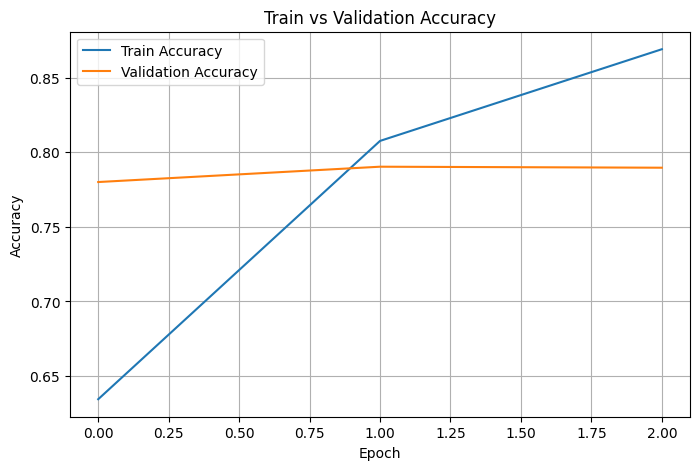

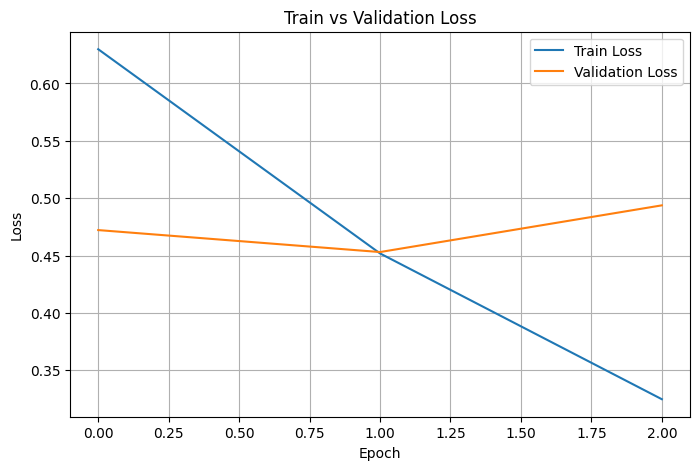

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Accuracy
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Train vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()


# =========================
# Loss
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Train vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()